**Setup and Imports**

In [ ]:
!pip install pykan -q
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
from kan import KAN
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Subset
from sklearn.decomposition import PCA
import torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.9 MB/s eta 0:00:00


# **Dataset Preparation for Classical KAN**
As I was working I found the implementation of KAN very computationally extensive so I take few steps to make it fast.
- We use a **smaller subset** of MNIST (e.g., 5000 training, 000 test samples) to **speed up experiments**.  
- Pixel values are normalized to the **0–1 range** for numerical stability.  
- **PCA** reduces 784 features to a smaller number (e.g., 50) to retain most variance while **reducing input size** for the Classical KAN.  
- Data is converted to PyTorch tensors and loaded in **mini-batches** for training.

**Data Prepration**

In [ ]:


transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load MNIST
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# Extract tensors from subset
X_train = train_dataset.data[:5000].view(-1, 784).float() / 255.0
X_test = test_dataset.data[:1000].view(-1, 784).float() / 255.0

y_train = train_dataset.targets[:5000]
y_test = test_dataset.targets[:1000]

# PCA
pca = PCA(n_components=50)

X_train_pca = torch.tensor(pca.fit_transform(X_train)).float()
X_test_pca = torch.tensor(pca.transform(X_test)).float()

# Create TensorDatasets
train_dataset_pca = TensorDataset(X_train_pca, y_train)
test_dataset_pca = TensorDataset(X_test_pca, y_test)

# DataLoaders
train_loader = DataLoader(train_dataset_pca, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset_pca, batch_size=128)

# **Classical KAN Model Parameters**

- **width:** Number of neurons in each layer (`[50, 32, 10]`)  
- **grid:** Number of spline points for each functional link (`3`)  
- **k:** Number of input components each spline depends on (`3`)  

In [39]:
model = KAN(
    width=[50, 32, 10],
    grid=3,
    k=3
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

checkpoint directory created: ./model
saving model version 0.0
cpu


# **Training the Classical KAN**

- **Optimizer:** Adam with learning rate 0.001  
- **Loss Function:** Cross-entropy for classification  
- **Epochs:** 15  
- **Progress Tracking:** `tqdm` shows per-batch loss for real-time monitoring  
- **Training Steps:**  
  1. Flatten input images  
  2. Forward pass through KAN model  
  3. Compute loss  
  4. Backpropagate and update functions  
  5. Track average loss per epoch

In [33]:
from tqdm import tqdm
import torch.optim as optim
import torch.nn.functional as F

optimizer = optim.Adam(model.parameters(), lr=1e-3)

epoch_losses = [] # Initialize a list to store losses for all epochs

for epoch in range(50):

    epoch_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for x, y in progress_bar:

        x = x.view(x.size(0), -1)

        logits = model(x)

        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    epoch_loss /= len(train_loader)
    epoch_losses.append(epoch_loss) # Store the average loss for the current epoch

    print(f"Epoch {epoch+1} Average Loss: {epoch_loss:.4f}")

Epoch 1: 100%|██████████| 40/40 [00:44<00:00,  1.11s/it, loss=0.095]


Epoch 1 Average Loss: 0.2619


Epoch 2: 100%|██████████| 40/40 [00:33<00:00,  1.21it/s, loss=0.0867]


Epoch 2 Average Loss: 0.2445


Epoch 3: 100%|██████████| 40/40 [00:34<00:00,  1.17it/s, loss=0.408]


...

Epoch 48 Average Loss: 0.0154


Epoch 49: 100%|██████████| 40/40 [00:34<00:00,  1.17it/s, loss=0.0346]


Epoch 49 Average Loss: 0.0152


Epoch 50: 100%|██████████| 40/40 [00:33<00:00,  1.20it/s, loss=0.0285]

Epoch 50 Average Loss: 0.0146


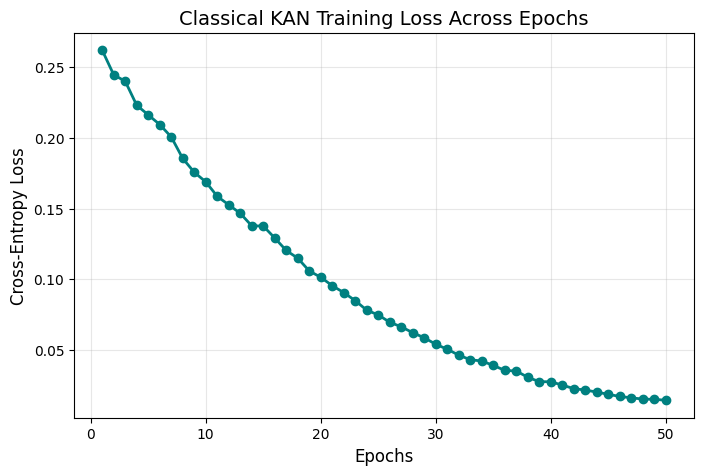

In [34]:
import matplotlib.pyplot as plt

# Now that epoch_losses is collected in the training loop, we can plot it.
epochs = range(1, len(epoch_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, epoch_losses, marker='o', color='teal', lw=2)
plt.title("Classical KAN Training Loss Across Epochs", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [37]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:

        # Flatten input images
        x = x.view(x.size(0), -1).to(device)
        y = y.to(device)

        # Forward pass
        logits = model(x)

        # Predicted class
        preds = torch.argmax(logits, dim=1)

        # Update metrics
        correct += (preds == y).sum().item()
        total += y.size(0)

# Final accuracy
accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 88.90%


## **Task IX: Extension to Quantum Kolmogorov-Arnold Networks (QKAN)**

### **1. Conceptual Ideas for Extension**
The classical KAN replaces fixed activation functions on nodes with learnable univariate functions (B-splines) on edges. To transition this to the quantum domain, we replace these classical splines with **Quantum Variational Circuits** or **Quantum Circuit Born Machines (QCBM)**.

* **Quantum Splines via Data Re-uploading:**
Instead of a B-spline grid, we can use a single-qubit or multi-qubit circuit where the input $x$ is "re-uploaded" multiple times through rotation gates. By interlacing these inputs with trainable entangling gates, the circuit can approximate any univariate nonlinear function $\phi(x)$, effectively acting as a "Quantum Spline".
* **Expressive Power of the Born Rule:** By using a QCBM approach, the network can learn probability distributions of quantum states. The "activation" is no longer just a curve but a quantum interference pattern, potentially offering higher expressivity for complex topological data like high-dimensional physics manifolds.
* **Hybrid Integration:** We can maintain the classical KAN structure but inject "Quantum Residuals." In this setup, the output is a sum of a classical SiLU function and a quantum circuit output, allowing the model to leverage classical stability with quantum-enhanced non-linearity.





# **2. Detailed QKAN Architecture Sketch**

The following architecture defines how a classical MNIST input (after PCA) is processed through a **Quantum KAN layer**.

---

##  **A. Functional Flow**

1. **Classical PCA Layer** Reduce the 784-pixel MNIST image to $N$ principal components $(x_1, x_2, \dots, x_N)$.

2. **Quantum Feature Map (Encoding)** Each component $x_i$ is mapped to a qubit using **Angle Encoding**:  
   $$|\psi(x)\rangle=\bigotimes_{i=1}^n R_y(\arctan(x_i))|0\rangle$$

3. **Learnable Quantum Edge (The Spline)** A **Variational Functional Ansatz** is applied to the qubits. This circuit consists of:  
   - **Entangling Layer:** CNOT gates to correlate different PCA features  
   - **Rotation Layer:** Trainable $R(\theta, \phi)$ gates that act as the "weights" of the quantum spline  

4. **Measurement (Expectation Values)** Measure the Pauli-Z expectation value for each qubit:  
   $$y_i=\langle \psi(x, \theta) | Z_i | \psi(x, \theta) \rangle$$
   to retrieve a scalar value.

5. **Output Aggregation** The results are summed classically to produce 10 logits for classification.

---

## **B. Structural Architecture Overview**

| Stage | Process | Component |
|-------|---------|-----------|
| I. Input | Dimensionality Reduction | PCA (Classical) |
| II. Encoding | State Preparation | $R_y(x_i)$ Feature Map |
| III. Processing | "Quantum Spline" | Parameterized Ansatz + Entanglers |
| IV. Readout | Information Retrieval | Expectation Values $\langle Z \rangle$ |
| V. Classification | Logit Summation | Softmax Layer (Classical) |

---

## **3. Training & Optimization**

The parameters $\theta$ of the Quantum Splines are optimized using a **hybrid approach**:

1. **Forward Pass:** Executed on a Quantum Simulator or Hardware  
2. **Backward Pass:** Since we cannot backpropagate through quantum hardware, we use the **Parameter-Shift Rule**:  

   $$\frac{\partial \langle Z \rangle}{\partial \theta}=\frac{\langle Z \rangle_{\theta + \pi/2} - \langle Z \rangle_{\theta - \pi/2}}{2}$$

   This analytically calculates the gradient by shifting the gate parameters by $\pm \pi/2$.

3. **Optimizer:** Standard **Adam** or **Adagrad** optimizers handle updates to both quantum and classical parameters.

### **Conclusion: Current Realities and Expectations**

While the theoretical transition from Classical KANs to Quantum KANs offers exciting possibilities for high-dimensional scientific computing, it is important to ground these architectures in current hardware and computational realities:

* **Classical KAN Reality:** Classical KANs excel in interpretability and can often learn complex scientific functions with fewer parameters than standard MLPs. However, replacing simple scalar weights with B-spline grids on every edge creates significant computational overhead. They are currently slower to train and infer on standard GPUs, which are heavily optimized for the dense matrix multiplications of traditional neural networks rather than localized spline evaluations.
* **Quantum KAN (QKAN) Reality:** QKANs hold the theoretical advantage of leveraging the vast expressivity of Hilbert space and quantum interference to map complex topological data. However, in the current NISQ (Noisy Intermediate-Scale Quantum) era, fully realized QKANs are bottlenecked by hardware limitations. Shallow circuit depth requirements, quantum noise, and the steep computational cost of calculating gradients via the Parameter-Shift rule mean that QKANs are currently restricted to proof-of-concept toy models or heavily dimensionality-reduced datasets.
* **The Near-Term Expectation:** The most realistic path forward in the immediate future is the **Hybrid architecture**. By using classical neural networks or classical KAN layers for the heavy lifting of feature extraction, and injecting small, targeted Quantum Variational Circuits only where extreme non-linearity or complex probability distributions (like QCBMs) are needed, we can begin to test quantum advantages without waiting for fully fault-tolerant quantum computers.